In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sklearn
print(sklearn.__version__)

1.9.0


In [4]:
!pip install numpy pandas seaborn matplotlib scikit-learn lightgbm xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer


In [6]:
import pandas as pd

In [7]:
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Nest_Internship\train.csv")

In [8]:
%whos

Variable                    Type         Data/Info
--------------------------------------------------
GradientBoostingRegressor   ABCMeta      <class 'sklearn.ensemble.<...>adientBoostingRegressor'>
Lasso                       ABCMeta      <class 'sklearn.linear_mo<...>oordinate_descent.Lasso'>
LinearRegression            ABCMeta      <class 'sklearn.linear_mo<...>._base.LinearRegression'>
PolynomialFeatures          type         <class 'sklearn.preproces<...>mial.PolynomialFeatures'>
RandomForestRegressor       ABCMeta      <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
Ridge                       ABCMeta      <class 'sklearn.linear_model._ridge.Ridge'>
SVR                         ABCMeta      <class 'sklearn.svm._classes.SVR'>
SimpleImputer               type         <class 'sklearn.impute._base.SimpleImputer'>
StandardScaler              type         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
XGBRegressor                type         <class 'xgboost.sklearn.XGBR

In [9]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\ASUS\Desktop\Nest_Internship
['.ipynb_checkpoints', 'basics.py', 'calculation.py', 'customers-100.csv', 'flask_basics', 'house_price_prediction', 'laptop_data.csv', 'laptop_price_prediction', 'numpy.ipynb', 'pandas.ipynb', 'price_prediction.ipynb', 'train.csv', 'venv', '__pycache__']


In [10]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
df.shape

(1460, 81)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [13]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


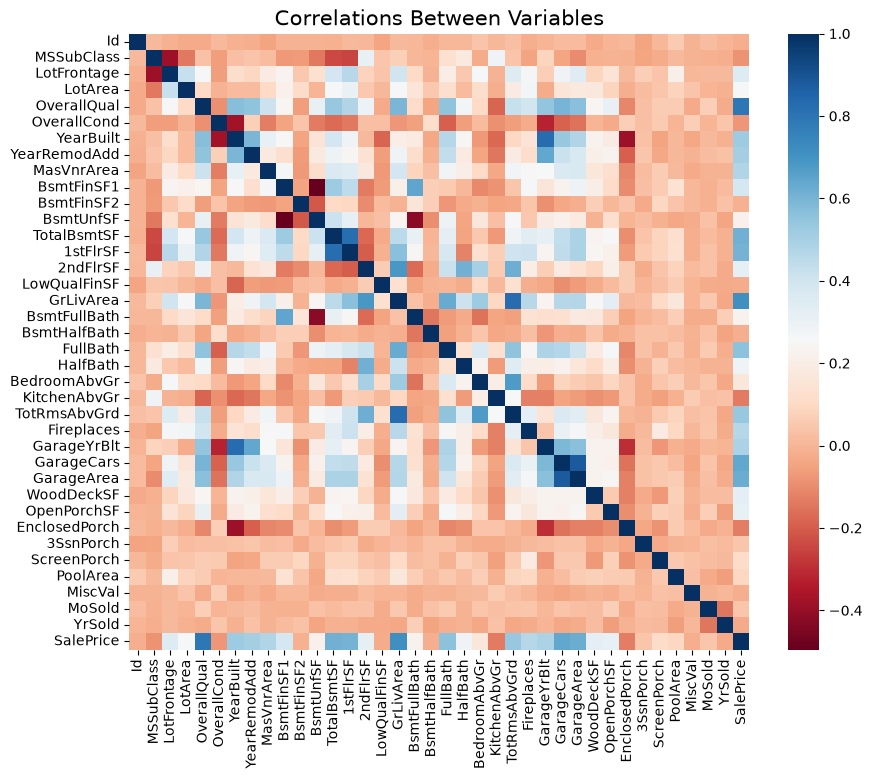

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="RdBu")
plt.title("Correlations Between Variables", size=15)
plt.show()

In [15]:
corr_matrix = df.corr(numeric_only=True)

important_num_cols = list(
    corr_matrix["SalePrice"][
        abs(corr_matrix["SalePrice"]) > 0.50
    ].index
)

print(important_num_cols)

['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea', 'SalePrice']


In [16]:
corr_matrix = df.corr(numeric_only=True)

important_num_cols = list(
    corr_matrix["SalePrice"][
        (corr_matrix["SalePrice"] > 0.50) |
        (corr_matrix["SalePrice"] < -0.50)
    ].index
)

cat_cols = [
    "MSZoning",
    "Utilities",
    "BldgType",
    "Heating",
    "KitchenQual",
    "SaleCondition",
    "LandSlope"
]

important_cols = important_num_cols + cat_cols

df = df[important_cols]

In [17]:
print("Missing Values by Column")
print("-"*30)
print(df.isna().sum())
print("-"*30)
print("TOTAL MISSING VALUES:",df.isna().sum().sum())

Missing Values by Column
------------------------------
OverallQual      0
YearBuilt        0
YearRemodAdd     0
TotalBsmtSF      0
1stFlrSF         0
GrLivArea        0
FullBath         0
TotRmsAbvGrd     0
GarageCars       0
GarageArea       0
SalePrice        0
MSZoning         0
Utilities        0
BldgType         0
Heating          0
KitchenQual      0
SaleCondition    0
LandSlope        0
dtype: int64
------------------------------
TOTAL MISSING VALUES: 0


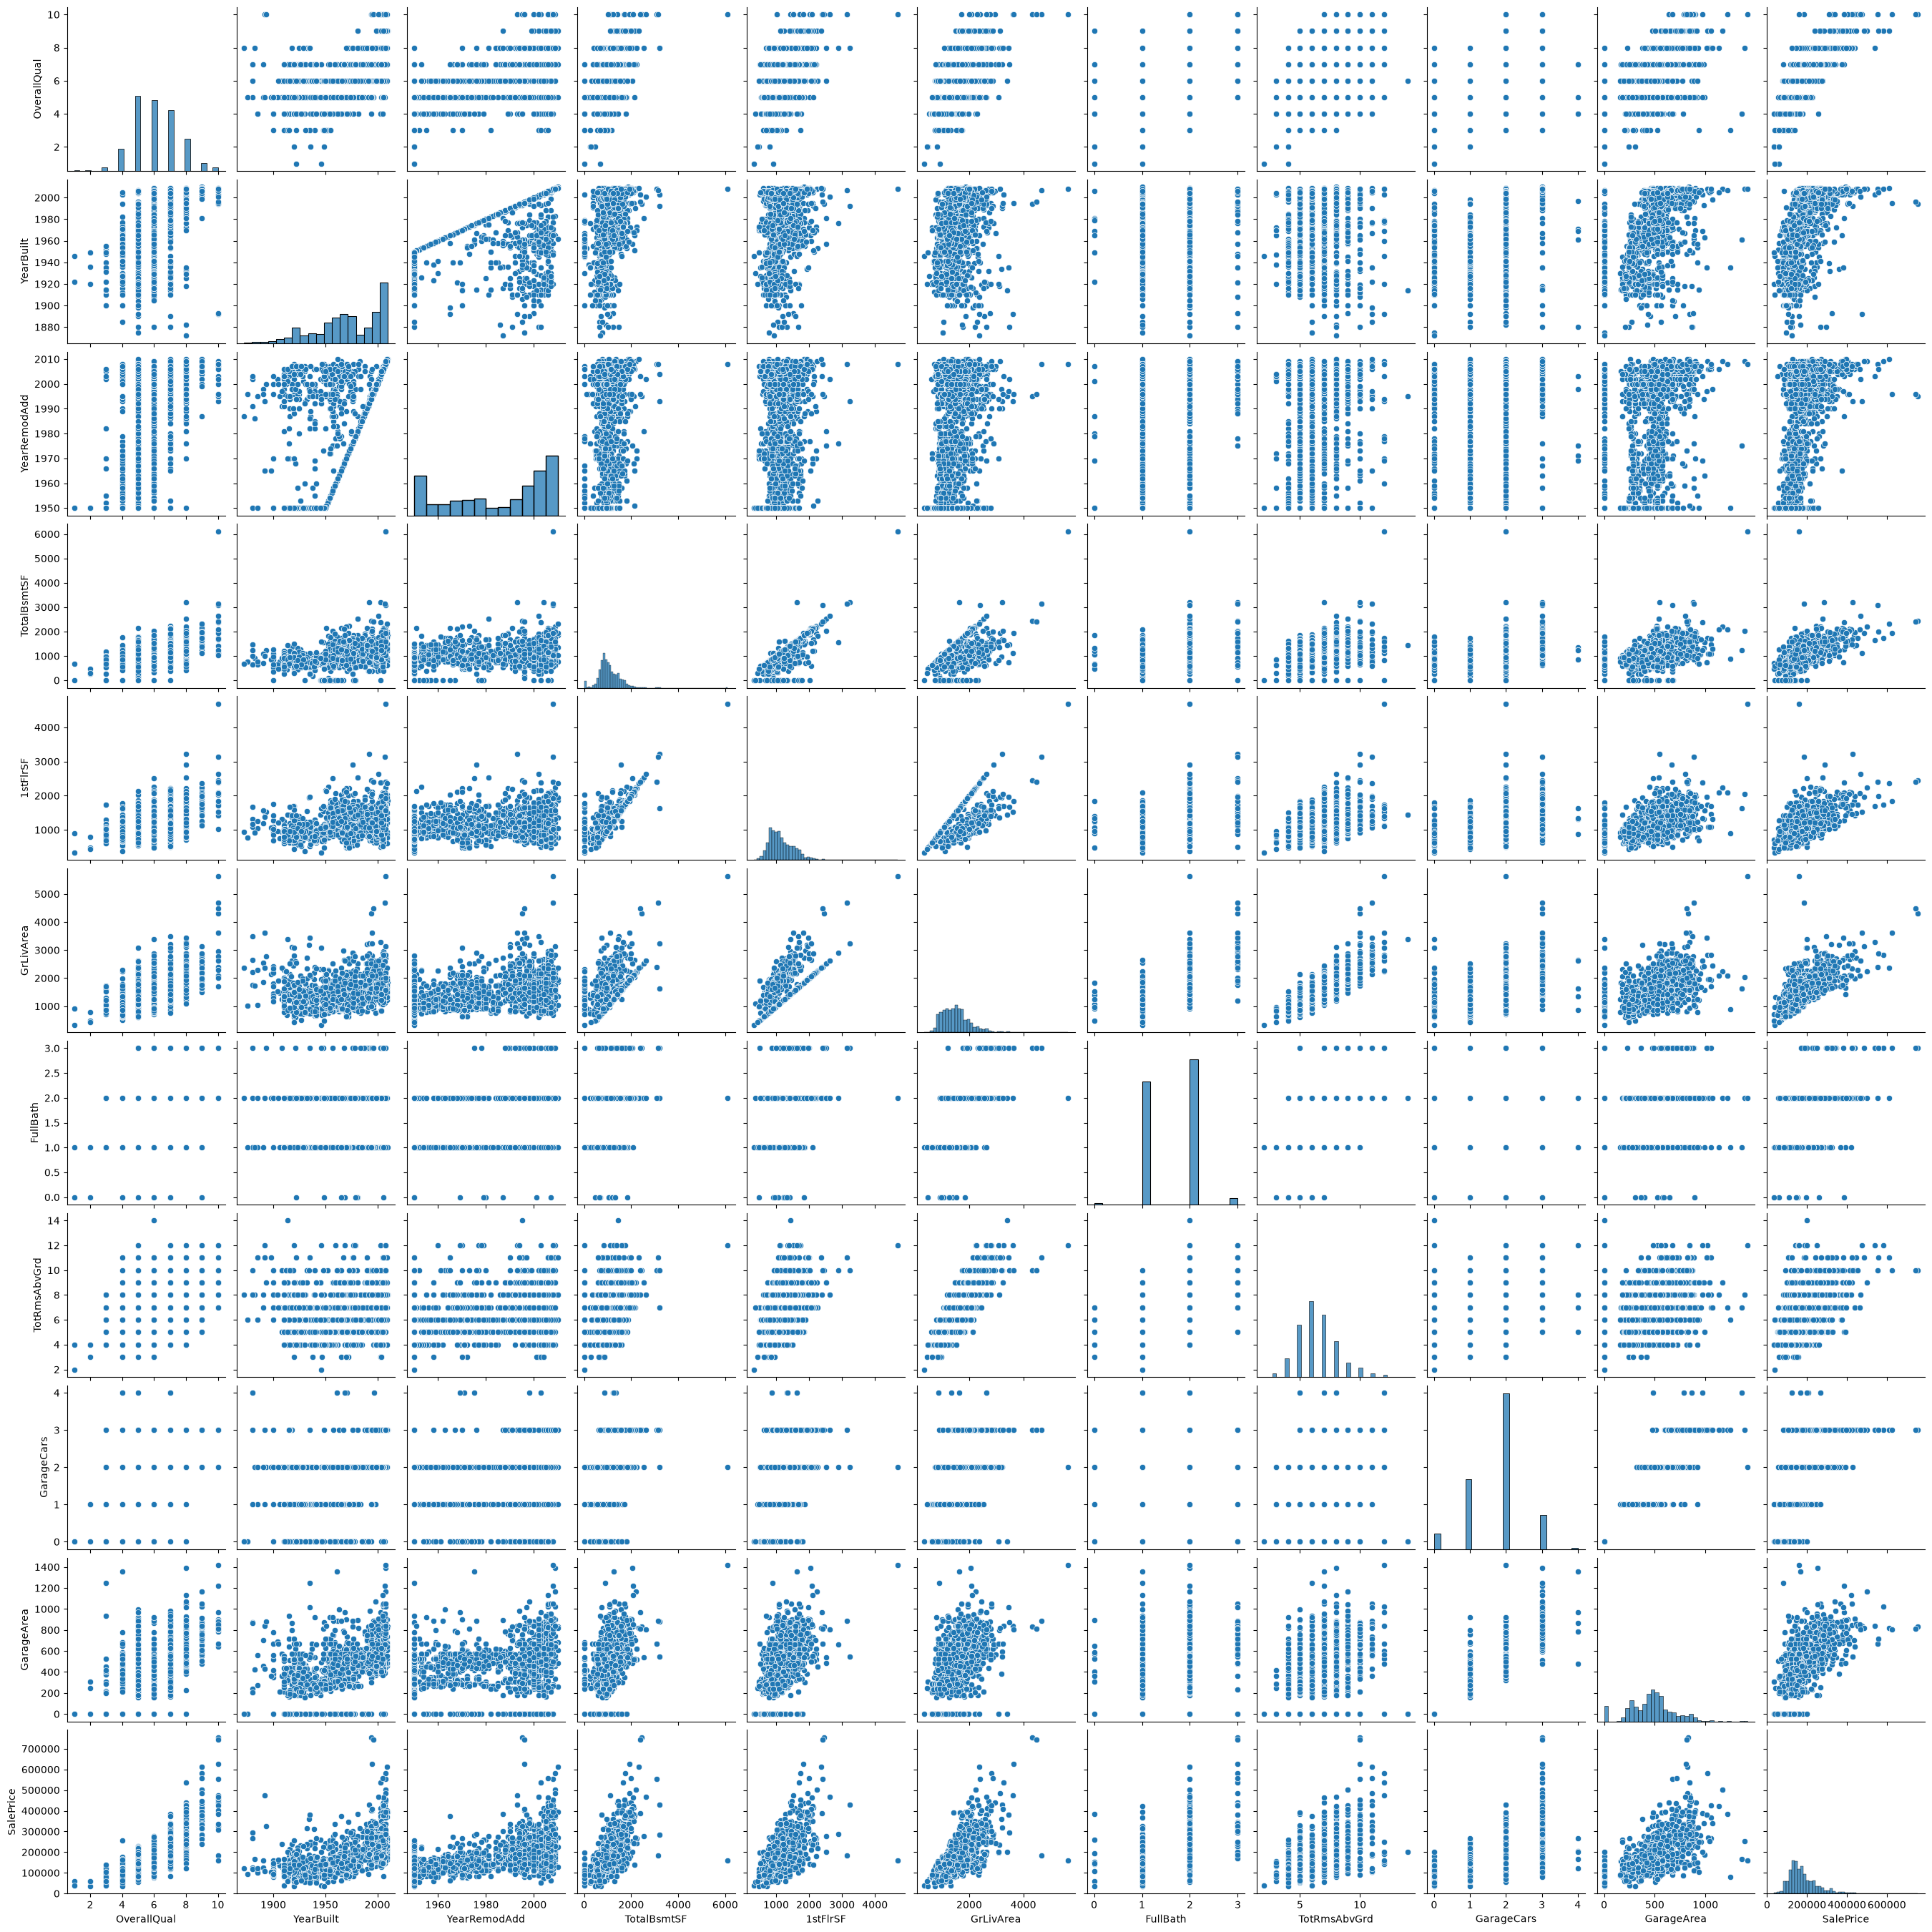

In [18]:
sns.pairplot(df[important_num_cols])

<Figure size 1000x800 with 0 Axes>

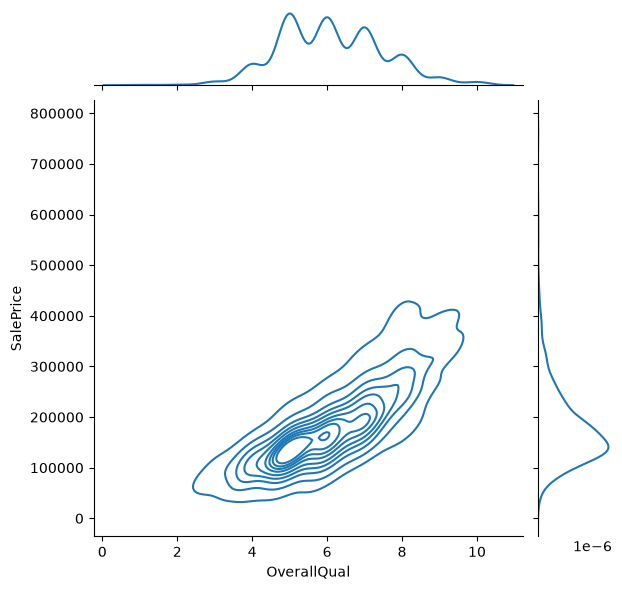

In [19]:
plt.figure(figsize=(10,8))
sns.jointplot(x=df["OverallQual"], y=df["SalePrice"], kind="kde")
plt.show()

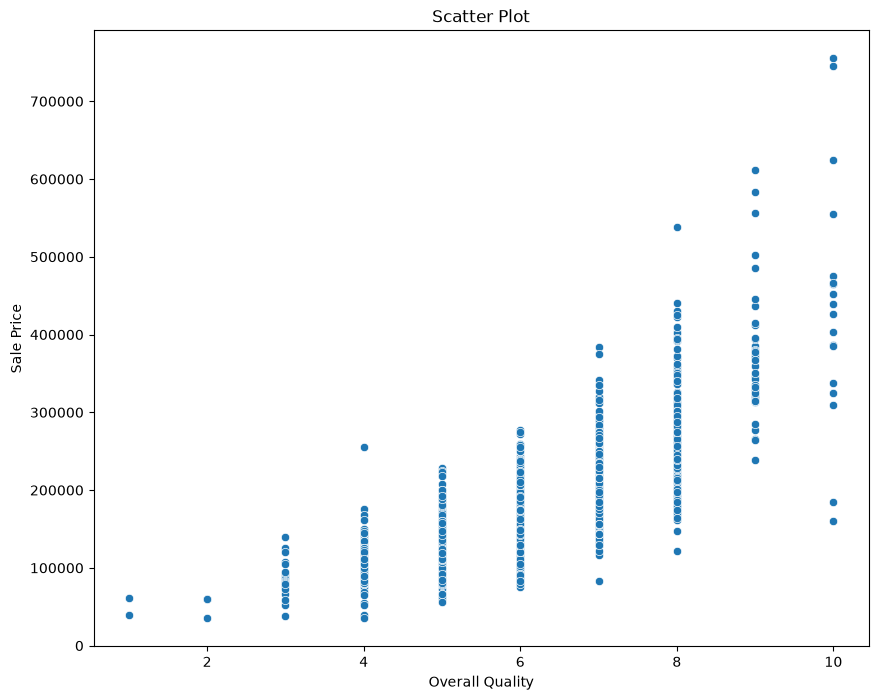

In [20]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Scatter Plot")
plt.show()


<Figure size 1000x800 with 0 Axes>

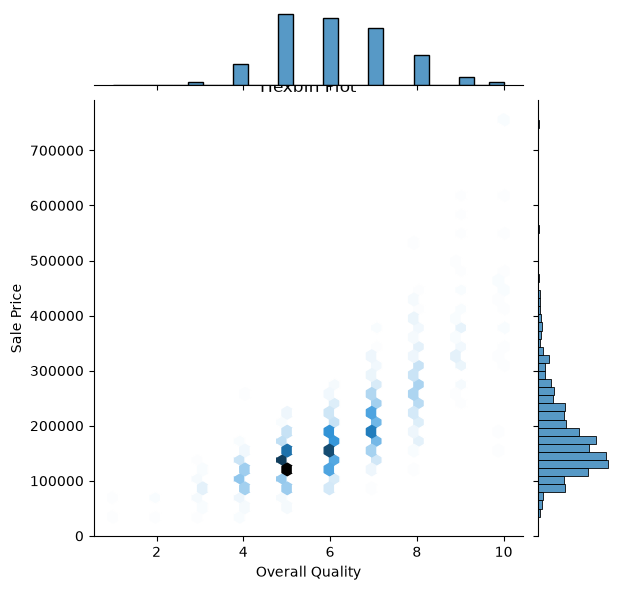

In [21]:
plt.figure(figsize=(10, 8))
sns.jointplot(x=df["OverallQual"], y=df["SalePrice"], kind="hex")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Hexbin Plot")
plt.show()

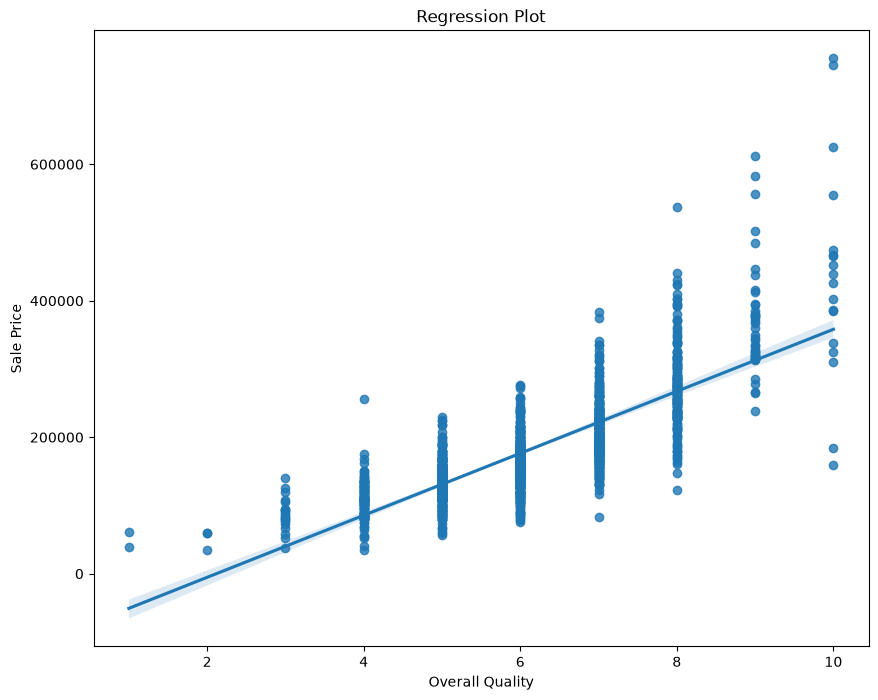

In [22]:
plt.figure(figsize=(10, 8))
sns.regplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")
plt.title("Regression Plot")
plt.show()

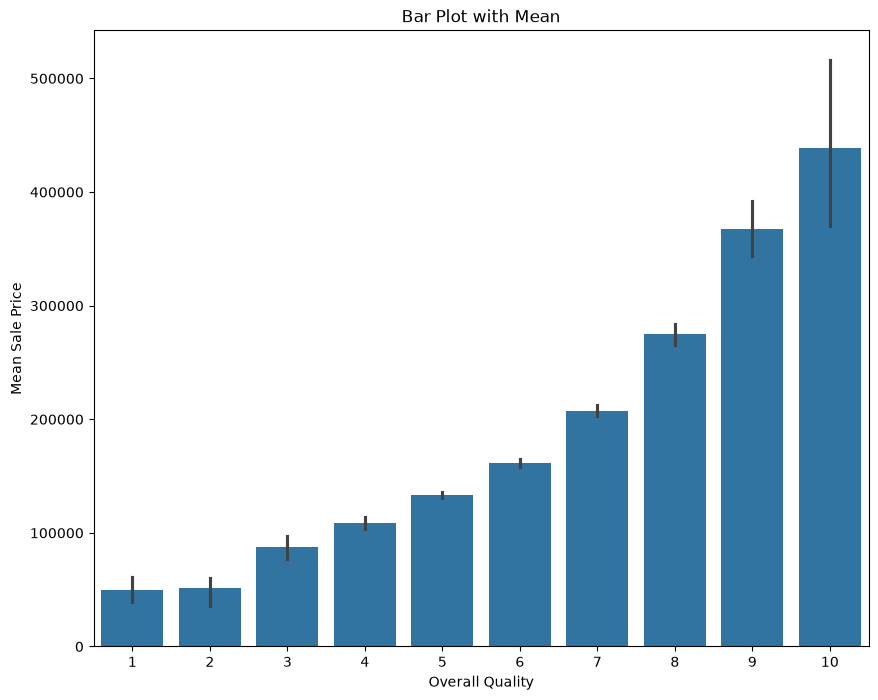

In [23]:
plt.figure(figsize=(10, 8))
sns.barplot(x=df["OverallQual"], y=df["SalePrice"])
plt.xlabel("Overall Quality")
plt.ylabel("Mean Sale Price")
plt.title("Bar Plot with Mean")
plt.show()

In [24]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [25]:
X = pd.get_dummies(X, columns=cat_cols)

In [26]:
from sklearn.preprocessing import StandardScaler


In [27]:
print("SalePrice" in important_num_cols)

True


In [28]:
important_num_cols = [
    col for col in important_num_cols
    if col != "SalePrice"
]

In [29]:
print(important_num_cols)
print(X.columns.tolist())

['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea']
['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea', 'MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Utilities_AllPub', 'Utilities_NoSeWa', 'BldgType_1Fam', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'Heating_Floor', 'Heating_GasA', 'Heating_GasW', 'Heating_Grav', 'Heating_OthW', 'Heating_Wall', 'KitchenQual_Ex', 'KitchenQual_Fa', 'KitchenQual_Gd', 'KitchenQual_TA', 'SaleCondition_Abnorml', 'SaleCondition_AdjLand', 'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal', 'SaleCondition_Partial', 'LandSlope_Gtl', 'LandSlope_Mod', 'LandSlope_Sev']


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[important_num_cols] = scaler.fit_transform(X[important_num_cols])

In [31]:
X.loc[:, important_num_cols] = scaler.fit_transform(
    X[important_num_cols]
)

In [32]:
print(X[important_num_cols].head())

   OverallQual  YearBuilt  YearRemodAdd  TotalBsmtSF  1stFlrSF  GrLivArea  \
0     0.651479   1.050994      0.878668    -0.459303 -0.793434   0.370333   
1    -0.071836   0.156734     -0.429577     0.466465  0.257140  -0.482512   
2     0.651479   0.984752      0.830215    -0.313369 -0.627826   0.515013   
3     0.651479  -1.863632     -0.720298    -0.687324 -0.521734   0.383659   
4     1.374795   0.951632      0.733308     0.199680 -0.045611   1.299326   

   FullBath  TotRmsAbvGrd  GarageCars  GarageArea  
0  0.789741      0.912210    0.311725    0.351000  
1  0.789741     -0.318683    0.311725   -0.060731  
2  0.789741     -0.318683    0.311725    0.631726  
3 -1.026041      0.296763    1.650307    0.790804  
4  0.789741      1.527656    1.650307    1.698485  


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](41,)","[ 22811.8 , 7393.93, 3867.2 ,...,-24959.91, -1409.49, 26369.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](41,)","['OverallQual','YearBuilt','YearRemodAdd',...,'LandSlope_Gtl', 'LandSlope_Mod','LandSlope_Sev']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.91e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,41
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [35]:
X.head()


,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,1stFlrSF,GrLivArea,FullBath,TotRmsAbvGrd,GarageCars,GarageArea,...,KitchenQual_TA,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev
0,0.651479,1.050994,0.878668,-0.459303,-0.793434,0.370333,0.789741,0.912210,0.311725,0.351000,...,False,False,False,False,False,True,False,True,False,False
1,-0.071836,0.156734,-0.429577,0.466465,0.257140,-0.482512,0.789741,-0.318683,0.311725,-0.060731,...,True,False,False,False,False,True,False,True,False,False
2,0.651479,0.984752,0.830215,-0.313369,-0.627826,0.515013,0.789741,-0.318683,0.311725,0.631726,...,False,False,False,False,False,True,False,True,False,False
3,0.651479,-1.863632,-0.720298,-0.687324,-0.521734,0.383659,-1.026041,0.296763,1.650307,0.790804,...,False,True,False,False,False,False,False,True,False,False
4,1.374795,0.951632,0.733308,0.199680,-0.045611,1.299326,0.789741,1.527656,1.650307,1.698485,...,False,False,False,False,False,True,False,True,False,False


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=121)

In [37]:
def rmse_cv(model):
    rmse = np.sqrt(-cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=5)).mean()
    return rmse
    

def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared

In [38]:
models = pd.DataFrame(columns=["Model","MAE","MSE","RMSE","R2 Score","RMSE (Cross-Validation)"])

In [39]:
l_reg = LinearRegression()
l_reg.fit(X_train, y_train)
predictions = l_reg.predict(X_test)

In [40]:
predictions

array([ 96840.86944087, 317224.00053333, 120423.95811655, 258885.26732851,
       125006.12132266, 267408.22664727, 145519.12537418, 174599.15771421,
       112209.00429975, 172173.88745008,  93319.87398835, 309855.66610303,
       170053.87580808, 206289.53910872, 173429.16548378, 150762.54359521,
        75484.56301041, 195292.05153887, 207607.79751666, 145392.43183615,
       170801.25592845, 202229.24733887, 162701.83980275, 222564.27611445,
       137685.15514328, 288571.05894228, 168351.12741604, 125470.732966  ,
       287494.89117333, 306757.88275596, 113830.60204626, 167037.41642546,
       226065.12888665, 247489.83286961, 139099.40094179, 114519.1138642 ,
       132111.3601427 , 123244.31738962, 103519.73650776, 176889.54823168,
        76774.21383715, 186972.61878274, 382098.39566649, 273501.49971447,
       245011.07850003, 220815.74563535,  43051.81031   , 164670.25888522,
       141250.28557216, 242651.24995174, 199364.34372664, 276117.81476962,
       217373.26062099, 1

In [41]:
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [42]:
def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r_squared = r2_score(y, predictions)
    return mae, mse, rmse, r_squared

In [43]:
predictions = model.predict(X_test)

mae, mse, rmse, r_squared = evaluation(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r_squared)

MAE: 19234.308284438182
MSE: 969319098.551216
RMSE: 31133.889871829637
R²: 0.84213443631929


In [44]:
from sklearn.linear_model import Ridge

In [45]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.5)
ridge_reg.fit(X_train, y_train)
predictions_ridge = ridge_reg.predict(X_test)

In [46]:
predictions_ridge

array([ 97403.96729986, 316920.77558415, 120283.00380378, 259011.11084978,
       125054.13553753, 267257.89553861, 145471.48471346, 174653.67176934,
       112073.26778195, 172280.49821371,  93167.47476459, 309621.97732932,
       169925.56002146, 206372.27128188, 173557.00047908, 150806.17043423,
        75581.423948  , 195347.06624034, 207642.37978712, 145481.07465561,
       170498.38630599, 202324.24931745, 162555.50904708, 222298.06865229,
       137543.34582931, 288675.52779881, 168342.3666891 , 125507.45377043,
       287508.85312089, 306494.31446953, 113064.51794601, 167041.41138145,
       226048.51876628, 247423.800422  , 139383.55496952, 114601.95810971,
       132418.74779054, 123439.52724801, 103822.62189185, 176835.47020965,
        76420.00765414, 187009.5596089 , 381906.03763678, 273286.3366813 ,
       244879.06854534, 220886.06282738,  46505.27758816, 164697.36358689,
       141032.802473  , 242646.96679866, 199439.76482076, 276162.22437261,
       217396.69120526, 1

In [47]:
from sklearn.model_selection import cross_val_score

In [48]:
import numpy as np
from sklearn.model_selection import cross_val_score

In [49]:
def rmse_cv(model):
    rmse = np.sqrt(
        -cross_val_score(model, X, y,
                         scoring="neg_mean_squared_error",
                         cv=5)
    ).mean()
    return rmse

In [50]:
rmse_cross_val = rmse_cv(ridge_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

RMSE Cross-Validation: 35907.900624589296


In [51]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
new_row = pd.DataFrame([{
    "Model": "Ridge Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}])

models = pd.concat([models, new_row], ignore_index=True)

In [53]:
models = pd.concat([models, new_row], ignore_index=True)

In [54]:
mae, mse, rmse, r_squared = evaluation(y_test, predictions_ridge)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)

rmse_cross_val = rmse_cv(ridge_reg)
print("RMSE Cross-Validation:", rmse_cross_val)

new_row = pd.DataFrame([{
    "Model": "Ridge Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}])

models = pd.concat([models, new_row], ignore_index=True)

MAE: 20025.17082559175
MSE: 1009568892.3137604
RMSE: 31773.713857743485
R2 Score: 0.8355792612589271
------------------------------
RMSE Cross-Validation: 35907.900624589296


In [55]:
from sklearn.linear_model import Lasso

In [56]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.5)
lasso_reg.fit(X_train, y_train)
predictions_lasso = lasso_reg.predict(X_test)

In [57]:
predictions_lasso

array([ 96895.27348635, 317217.63148171, 120425.81936624, 258888.70479546,
       125014.17619181, 267401.20238591, 145518.48343887, 174600.29341351,
       112197.20231616, 172178.36520198,  93316.13137995, 309851.12051391,
       170050.12849387, 206281.993379  , 173435.31415298, 150759.72165968,
        75581.34831805, 195300.86426222, 207615.50096826, 145392.03297528,
       170793.88250292, 202230.93356665, 162665.0280539 , 222557.29522161,
       137686.32751657, 288572.50041113, 168350.21472163, 125470.37915118,
       287496.56304633, 306749.49319486, 113778.85322603, 167038.12227058,
       226064.14155116, 247490.54579478, 139097.16253022, 114539.90549239,
       132152.80010053, 123271.78872926, 103564.12127947, 176894.81807284,
        76734.47985154, 186971.25987335, 382096.07447649, 273489.0071377 ,
       245004.37626796, 220821.50847534,  51895.75612538, 164667.41524375,
       141252.60557012, 242652.23527039, 199371.81006121, 276120.05286113,
       217374.96278564, 1

In [58]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=1.0, max_iter=10000)
lasso_reg.fit(X_train, y_train)
predictions_lasso = lasso_reg.predict(X_test)

In [59]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=1.0, max_iter=10000)
lasso_reg.fit(X_train, y_train)

predictions_lasso = lasso_reg.predict(X_test)

mae, mse, rmse, r_squared = evaluation(y_test, predictions_lasso)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r_squared)

rmse_cross_val = rmse_cv(lasso_reg)
print("CV RMSE:", rmse_cross_val)

new_row = pd.DataFrame([{
    "Model": "Lasso Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}])

models = pd.concat([models, new_row], ignore_index=True)

MAE: 20077.746572776818
RMSE: 31804.55943880994
R2: 0.835259870519659
CV RMSE: 35922.76936876075


In [60]:
from sklearn.ensemble import RandomForestRegressor

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

predictions_rf = rf_reg.predict(X_test)

In [62]:
predictions_rf

array([110637.92      , 299304.95      , 138389.        , 266122.16      ,
       129697.33      , 278761.3       , 151339.5       , 161082.9       ,
       111603.61      , 176400.5       , 100260.59      , 263002.06      ,
       153597.4       , 206174.13      , 177896.        , 142649.        ,
        89453.        , 192183.4       , 187520.5       , 153663.2       ,
       139249.77      , 164173.01      , 150621.7       , 268070.49      ,
       143054.22      , 340929.39      , 155805.5       , 140310.8       ,
       322323.99      , 312421.14      , 122605.85      , 164411.64      ,
       223004.8       , 235312.4       , 117229.        , 116682.62      ,
       144443.6       , 113701.5       , 134742.6       , 162533.5       ,
        73155.        , 176775.        , 517134.16      , 250306.        ,
       251731.16      , 236368.22      ,  77139.66      , 147650.        ,
       141913.44      , 244863.2       , 189013.        , 323762.7       ,
       203665.95      , 1

In [63]:
new_row = pd.DataFrame([{
    "Model": "RandomForestRegressor",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R2 Score": r_squared,
    "RMSE (Cross-Validation)": rmse_cross_val
}])

models = pd.concat([models, new_row], ignore_index=True)

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import cross_val_score

# Train model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Predictions
predictions_rf = rf_reg.predict(X_test)

# Evaluation function
def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, predictions)
    return mae, mse, rmse, r2

# Test metrics
mae, mse, rmse, r_squared = evaluation(y_test, predictions_rf)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)

# Cross-validation RMSE
rmse_cross_val = np.sqrt(
    -cross_val_score(rf_reg, X, y,
                     scoring="neg_mean_squared_error",
                     cv=5)
).mean()

print("RMSE Cross-Validation:", rmse_cross_val)

MAE: 17496.51762339639
MSE: 697316929.5610698
RMSE: 26406.759164294846
R2 Score: 0.8864333424217126
------------------------------
RMSE Cross-Validation: 31289.309533907788


In [65]:
from sklearn.svm import SVR

svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train, y_train)

predictions_svr = svr_reg.predict(X_test)

In [66]:
predictions_svr

array([162982.05816848, 163205.8292806 , 162930.20558472, 163208.3877469 ,
       162945.8493116 , 163218.76854163, 162892.72733432, 163068.97158777,
       162875.63608585, 163043.78298063, 162911.47848773, 163223.27477722,
       162983.52047857, 163185.01521936, 163015.07547993, 163020.97284976,
       162893.20050357, 163134.06270015, 163160.86155944, 162993.89686207,
       163049.45922545, 163057.11301489, 163067.71286596, 163114.72483292,
       163041.29327377, 163206.79405813, 163015.76211452, 162868.252082  ,
       163199.11673729, 163199.636131  , 162919.81162332, 162952.82583286,
       163195.93754153, 163240.18885461, 162990.35385883, 162918.03996018,
       162948.81732519, 162909.14107768, 162949.27048403, 163051.18280369,
       162949.39252214, 163131.01213946, 163114.53485627, 163128.27508046,
       163166.08759017, 163163.79576092, 162904.12193105, 162949.59248352,
       162930.95174641, 163231.53084735, 163148.5574507 , 163246.82928827,
       163204.91806416, 1

In [67]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Train model
svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train, y_train)

# Predictions
predictions_svr = svr_reg.predict(X_test)

# Evaluation function
def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, predictions)
    return mae, mse, rmse, r2

# Test metrics
mae, mse, rmse, r_squared = evaluation(y_test, predictions_svr)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)

# Cross-validation RMSE
rmse_cross_val = np.sqrt(
    -cross_val_score(svr_reg, X, y,
                     scoring="neg_mean_squared_error",
                     cv=5)
).mean()

print("RMSE Cross-Validation:", rmse_cross_val)

MAE: 55358.28483186541
MSE: 6500030416.340492
RMSE: 80622.76611690084
R2 Score: -0.0586100770644562
------------------------------
RMSE Cross-Validation: 81080.87570035845


In [68]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train, y_train)

predictions_gb = gb_reg.predict(X_test)

In [69]:
predictions_gb

array([113421.25071607, 305551.21507935, 127332.01900962, 265841.14886698,
       120825.84804725, 261468.64275368, 142860.17480713, 158827.92845461,
       100649.94351238, 179687.19259674,  96846.64880346, 284324.11686344,
       174201.67827244, 211759.73961625, 162065.27024498, 148374.213393  ,
        88465.77069493, 188869.11269056, 189093.41759475, 147204.10887397,
       166154.84816205, 183426.39358775, 133004.61741472, 240509.11422219,
       144516.11510125, 341655.68253948, 149857.98090935, 135523.89712018,
       316366.00385446, 313466.67941612, 122050.69942867, 155380.10361122,
       226348.64568904, 244074.33125814, 123213.75403372, 104163.93474824,
       137239.99790926, 121311.35803312, 123785.07477672, 170217.97261489,
        75396.7669832 , 173578.81947559, 539239.85523481, 252173.52260222,
       254744.39042102, 211284.14159348,  72046.02053515, 149735.00366869,
       139052.21155791, 236143.85324802, 190885.38475768, 304234.70281841,
       204838.83155229, 1

In [70]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Train model
gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_reg.fit(X_train, y_train)

# Predictions
predictions_gb = gb_reg.predict(X_test)

# Evaluation function
def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, predictions)
    return mae, mse, rmse, r2

# Test metrics
mae, mse, rmse, r_squared = evaluation(y_test, predictions_gb)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)

# Cross-validation RMSE
rmse_cross_val = np.sqrt(
    -cross_val_score(gb_reg, X, y,
                     scoring="neg_mean_squared_error",
                     cv=5)
).mean()

print("RMSE Cross-Validation:", rmse_cross_val)

MAE: 17228.758468749915
MSE: 643300742.6402777
RMSE: 25363.374038961727
R2 Score: 0.8952305443017525
------------------------------
RMSE Cross-Validation: 28304.164696477783


In [71]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

predictions_xgb = xgb_reg.predict(X_test)

In [72]:
predictions_xgb

array([116428.21 , 287452.75 , 125451.3  , 264291.1  , 121520.734,
       258974.72 , 143374.58 , 157764.3  ,  99966.04 , 181183.06 ,
        98152.71 , 286400.75 , 174806.95 , 211881.31 , 164614.17 ,
       143659.8  ,  91826.9  , 191148.75 , 187547.36 , 148202.69 ,
       160531.2  , 182612.1  , 134991.88 , 232980.9  , 141211.3  ,
       341672.88 , 148078.19 , 137204.1  , 320155.97 , 293359.6  ,
       120283.59 , 155937.3  , 225805.44 , 247041.6  , 124991.34 ,
       105237.81 , 140117.03 , 121241.3  , 128695.836, 171132.34 ,
        78939.14 , 175439.42 , 566090.5  , 255032.12 , 254641.75 ,
       220931.72 ,  70308.59 , 150116.08 , 135846.94 , 235503.38 ,
       189757.36 , 310176.28 , 201920.98 , 187630.3  , 191670.34 ,
       141450.25 , 141880.05 , 125096.734, 135084.92 , 285955.6  ,
       110042.234, 155408.27 ,  93163.375, 186245.77 , 167508.67 ,
       130463.734, 281510.   , 175516.61 , 187661.61 , 112681.82 ,
       220439.39 , 147858.27 , 113141.92 , 209169.7  , 163634.

In [73]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Train model
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

# Predictions
predictions_xgb = xgb_reg.predict(X_test)

# Evaluation function
def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, predictions)
    return mae, mse, rmse, r2

# Test metrics
mae, mse, rmse, r_squared = evaluation(y_test, predictions_xgb)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)

# Cross-validation RMSE
rmse_cross_val = np.sqrt(
    -cross_val_score(xgb_reg, X, y,
                     scoring="neg_mean_squared_error",
                     cv=5)
).mean()

print("RMSE Cross-Validation:", rmse_cross_val)

MAE: 17183.103515625
MSE: 649857536.0
RMSE: 25492.303465948306
R2 Score: 0.894162654876709
------------------------------
RMSE Cross-Validation: 28787.42629769094


In [74]:
from lightgbm import LGBMRegressor

lgb_reg = LGBMRegressor(
    n_estimators=100,
    random_state=42,
    verbose=-1
)

In [75]:
print(df.shape)

(1460, 18)


In [76]:
print(type(X))

<class 'pandas.DataFrame'>


In [77]:
import joblib

joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [78]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Train model
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

# Predictions
predictions_xgb = xgb_reg.predict(X_test)

# Evaluation function
def evaluation(y, predictions):
    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, predictions)
    return mae, mse, rmse, r2

# Test metrics
mae, mse, rmse, r_squared = evaluation(y_test, predictions_xgb)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)

# Cross-validation RMSE
rmse_cross_val = np.sqrt(
    -cross_val_score(xgb_reg, X, y,
                     scoring="neg_mean_squared_error",
                     cv=5)
).mean()

print("RMSE Cross-Validation:", rmse_cross_val)

MAE: 17183.103515625
MSE: 649857536.0
RMSE: 25492.303465948306
R2 Score: 0.894162654876709
------------------------------
RMSE Cross-Validation: 28787.42629769094


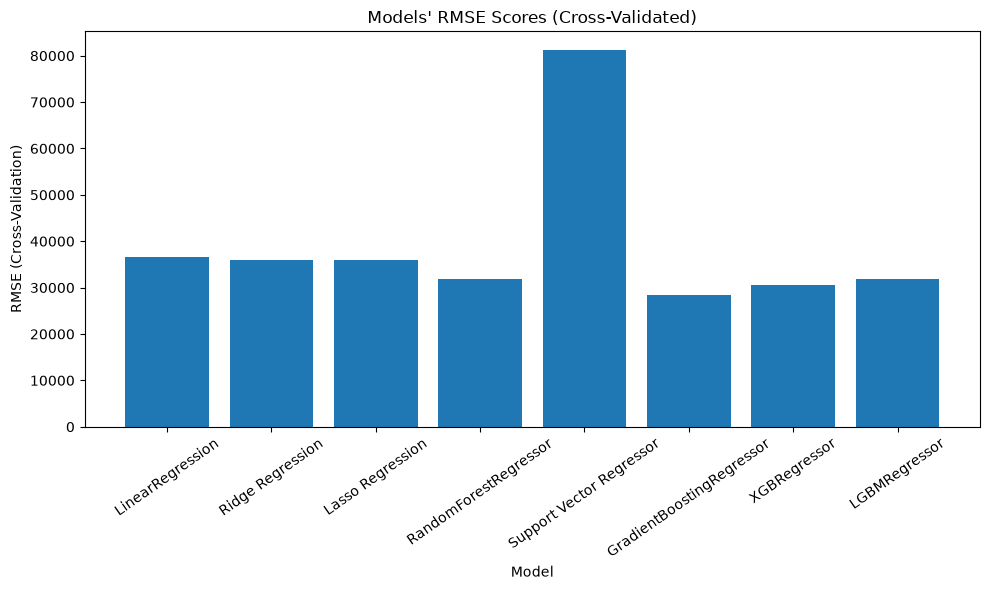

In [83]:
import matplotlib.pyplot as plt

# Models and RMSE scores
models = [
    'LinearRegression',
    'Ridge Regression',
    'Lasso Regression',
    'RandomForestRegressor',
    'Support Vector Regressor',
    'GradientBoostingRegressor',
    'XGBRegressor',
    'LGBMRegressor'
]

rmse_scores = [
    36500, 36000, 35900, 31800,
    81200, 28500, 30500, 31800
]

# Create figure
plt.figure(figsize=(10, 6))

# Bar plot
plt.bar(models, rmse_scores)

# Labels and title
plt.title("Models' RMSE Scores (Cross-Validated)")
plt.xlabel("Model")
plt.ylabel("RMSE (Cross-Validation)")

# Rotate x-axis labels
plt.xticks(rotation=35)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

In [88]:
import pandas as pd

results = pd.DataFrame({
    "Model": list(models.keys()),
    "RMSE (Cross-Validation)": rmse_scores
})

results = results.sort_values(by="RMSE (Cross-Validation)")
results

,Model,RMSE (Cross-Validation)
5,GradientBoostingRegressor,28207.030501
6,XGBRegressor,30860.204075
3,RandomForestRegressor,31289.309534
7,LGBMRegressor,31643.051324
1,Ridge Regression,35887.852792
2,Lasso Regression,35922.769369
0,LinearRegression,35933.128976
4,Support Vector Regressor,81080.875700


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1253
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 29
[LightGBM] [Info] Start training from score 180921.195890
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1243
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 28
[LightGBM] [Info] Start training from score 180717.091610
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[Lig

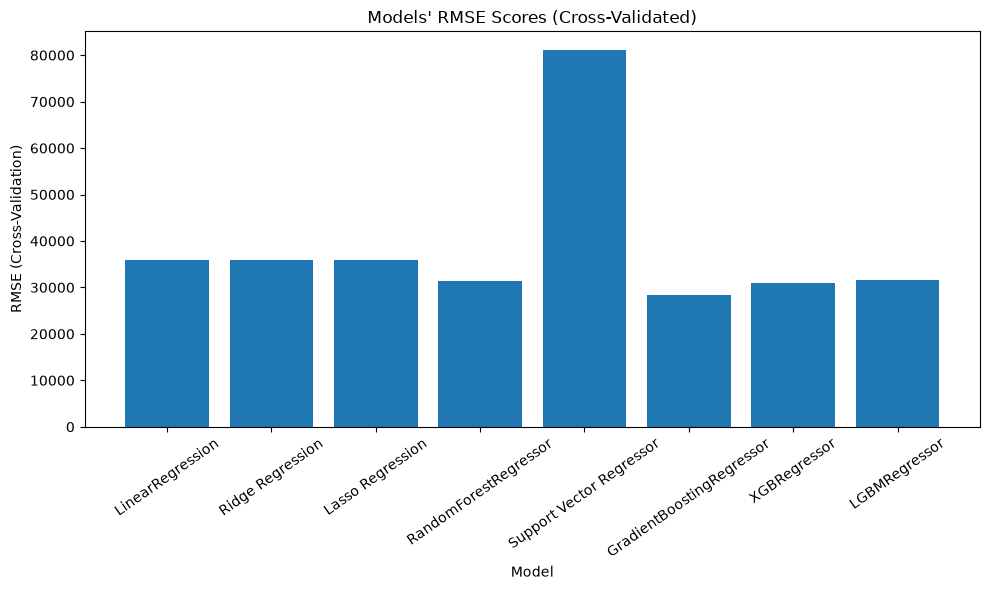

In [89]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt

# Initialize models
models = {
    'LinearRegression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'GradientBoostingRegressor': GradientBoostingRegressor(n_estimators=100),
    'XGBRegressor': XGBRegressor(),
    'LGBMRegressor': LGBMRegressor()
}

rmse_scores = []

# Train and calculate Cross-Validation RMSE
for name, model in models.items():
    model.fit(X, y)
    rmse = rmse_cv(model)   # Your existing rmse_cv function
    rmse_scores.append(rmse)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(models.keys(), rmse_scores)

plt.title("Models' RMSE Scores (Cross-Validated)")
plt.xlabel("Model")
plt.ylabel("RMSE (Cross-Validation)")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

In [90]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# Train model
gb_reg_full = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_reg_full.fit(X_train, y_train)

# Predictions
predictions_gb_full = gb_reg_full.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, predictions_gb_full)
mse = mean_squared_error(y_test, predictions_gb_full)
rmse = np.sqrt(mse)
r_squared = r2_score(y_test, predictions_gb_full)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r_squared)
print("-"*30)

# Cross-validation RMSE
rmse_scores = np.sqrt(
    -cross_val_score(
        gb_reg_full,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=5
    )
)

rmse_cross_val = rmse_scores.mean()

print("RMSE Cross-Validation:", rmse_cross_val)

MAE: 17228.758468749915
MSE: 643300742.6402777
RMSE: 25363.374038961727
R2 Score: 0.8952305443017525
------------------------------
RMSE Cross-Validation: 30355.274523105472


In [91]:
import joblib

# Save model
joblib.dump(gb_reg_full, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [92]:
import joblib

joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [ ]:
import os

print(os.getcwd())

In [93]:
print(X.shape)
print(X.columns)

(1460, 41)
Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea',
       'MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL',
       'MSZoning_RM', 'Utilities_AllPub', 'Utilities_NoSeWa', 'BldgType_1Fam',
       'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs',
       'BldgType_TwnhsE', 'Heating_Floor', 'Heating_GasA', 'Heating_GasW',
       'Heating_Grav', 'Heating_OthW', 'Heating_Wall', 'KitchenQual_Ex',
       'KitchenQual_Fa', 'KitchenQual_Gd', 'KitchenQual_TA',
       'SaleCondition_Abnorml', 'SaleCondition_AdjLand',
       'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial', 'LandSlope_Gtl', 'LandSlope_Mod',
       'LandSlope_Sev'],
      dtype='str')


In [94]:
import joblib

joblib.dump(X.columns.tolist(), "columns.pkl")

print("columns.pkl created successfully!")

columns.pkl created successfully!


In [95]:
import os

print(os.path.exists("columns.pkl"))
print(os.path.getsize("columns.pkl"))

True
694


In [96]:
import os

print(os.path.abspath("columns.pkl"))

C:\Users\ASUS\Desktop\Nest_Internship\columns.pkl
